# **Data Loader test**
---

### Initialize libraries and modules:

In [1]:
import sys
from pathlib import Path

from importlib import reload

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [2]:
import src._dev.data_simulators as data_simulators_module
reload(data_simulators_module)
craft_dummy_dataframe = data_simulators_module.craft_dummy_dataframe

#### A helper for dummy dataset generation:

### Define paths of files or directories from which data will be loaded:

Merged csv with included (sub)categories (no metadata)

In [3]:
df, path_simulated_csv = craft_dummy_dataframe(
    categories={
        'set': ['set_A', 'set_B'],
        'subset': ['subset_1', 'subset_2'],
    },
    save='single',
    out_dir='dummy_data',
)

Tree like directory with multiple (sub)categories and files (no metadata)

In [4]:
# Full 4-level hierarchy written as a directory tree
df, paths_simulated_tree = craft_dummy_dataframe(
    n_tracks=3,
    categories={
        'set': ['set_A', 'set_B'],
        'subset': ['subset_1', 'subset_2'],
        'group': ['ctrl', 'treated'],
        'subgroup': ['rep1', 'rep2'],
    },
    save='tree',
    out_dir='dummy_data',
    n_files=3,
    seed=42
)

dir_simulated_tree = r"dummy_data/tree"

In [5]:
path_trackmate_xml = r"C:\Users\modri\Desktop\img_sq.xml"

In [6]:
path_trackmate_csv = r"C:\Users\modri\Desktop\position_0003440_allspots.csv"

In [7]:
import src.loader.load as load_module
from importlib import reload

reload(load_module)
load_data = load_module.load_data

In [8]:
df_trackmate_xml = load_data(path_trackmate_xml, invert_y=True)

In [9]:
df_trackmate_csv = load_data(path_trackmate_csv, invert_y=True)

In [10]:
df_trackmate_csv_converted = load_data(path_trackmate_csv, convert_time_to='min', convert_spatial_to='meters')

In [11]:
df_simulated_csv = load_data(
    path_simulated_csv,
    {
        'id': 'track_id',
        't': 'time_point',
        'x': 'x_coordinate',
        'y': 'y_coordinate',
    },
)

C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\loader\load.py:184: InputWarning: No time units found in input files.
 Please specify the time units using <load_data result>.metadata.write(time_unit="<unit>")
  self._check()
C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\loader\load.py:184: InputWarning: No spatial units found in input files.
 Please specify the spatial units using <load_data result>.metadata.write(spatial_unit="<unit>")
  self._check()


In [12]:
df_simulated_csv.metadata.write(spatialunits='microns', timeunits='seconds')

In [13]:
df_simulated_csv = load_data(
    path_simulated_csv,
    {
        'id': 'track_id',
        't': 'time_point',
        'x': 'x_coordinate',
        'y': 'y_coordinate',
    },
    spatial_unit='meter', time_unit='sec'
)

In [14]:
import src.batch.tree as bath_tree_module
reload(bath_tree_module)
make_tree = bath_tree_module.make_tree

In [15]:
tree = make_tree(dir_simulated_tree)
tree.show()

paths_simulated_tree = tree.get()

tree
├── set_A
│   ├── subset_1
│   │   ├── ctrl
│   │   │   ├── rep1
│   │   │   │   ├── dummy_cell_tracks_0.csv
│   │   │   │   ├── dummy_cell_tracks_1.csv
│   │   │   │   └── dummy_cell_tracks_2.csv
│   │   │   └── rep2
│   │   │       ├── dummy_cell_tracks_0.csv
│   │   │       ├── dummy_cell_tracks_1.csv
│   │   │       └── dummy_cell_tracks_2.csv
│   │   └── treated
│   │       ├── rep1
│   │       │   ├── dummy_cell_tracks_0.csv
│   │       │   ├── dummy_cell_tracks_1.csv
│   │       │   └── dummy_cell_tracks_2.csv
│   │       └── rep2
│   │           ├── dummy_cell_tracks_0.csv
│   │           ├── dummy_cell_tracks_1.csv
│   │           └── dummy_cell_tracks_2.csv
│   └── subset_2
│       ├── ctrl
│       │   ├── rep1
│       │   │   ├── dummy_cell_tracks_0.csv
│       │   │   ├── dummy_cell_tracks_1.csv
│       │   │   └── dummy_cell_tracks_2.csv
│       │   └── rep2
│       │       ├── dummy_cell_tracks_0.csv
│       │       ├── dummy_cell_tracks_1.csv
│       │       └── dum

In [16]:
df_simulated_tree = load_data(
    paths_simulated_tree,
    {
        'id': 'track_id',
        't': 'time_point',
        'x': 'x_coordinate',
        'y': 'y_coordinate',
    },
    spatial_unit='um', time_unit='sec'
)

In [17]:
data = [
    df_trackmate_xml,
    df_trackmate_csv,
    df_trackmate_csv_converted,
    df_simulated_csv,
    df_simulated_tree,
]

In [18]:
for d in data:
    display(d)
    print(d.metadata.get())
    print(d.metadata.get_each())

    assert d.metadata.get('spatialunits') in ['nm', 'μm', 'mm', 'cm', 'm']
    assert d.metadata.get('timeunits') in ['ns', 'μs', 'ms', 's', 'min', 'h', 'd']

track_id,time_point,x_coordinate,y_coordinate,set
f64,f64,f64,f64,str
149.0,0.0,107.037336,885.08804,"""img_sq.xml"""
153.0,0.0,618.601983,885.08804,"""img_sq.xml"""
154.0,0.0,669.536991,885.08804,"""img_sq.xml"""
155.0,0.0,720.471999,885.08804,"""img_sq.xml"""
156.0,0.0,971.456097,885.08804,"""img_sq.xml"""
…,…,…,…,…
141.0,8010.0,668.458968,9.136611,"""img_sq.xml"""
1529.0,8010.0,830.026108,5.962488,"""img_sq.xml"""
1577.0,8010.0,487.942614,0.0,"""img_sq.xml"""


{'timeunits': 's', 'spatialunits': 'μm', 'nframes': 90, 'timestep': 90.0, 'columns': ['TRACK_ID', 'ID', 'name', 'STD_INTENSITY_CH1', 'QUALITY', 'POSITION_T', 'MIN_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'CONTRAST_CH1', 'SNR_CH1', 'FRAME', 'MEDIAN_INTENSITY_CH1', 'VISIBILITY', 'RADIUS', 'POSITION_X', 'POSITION_Y', 'MEAN_INTENSITY_CH1', 'POSITION_Z', 'MAX_INTENSITY_CH1']}
{'img_sq.xml': {'TRACK_ID': '', 'POSITION_T': 's', 'POSITION_X': 'μm', 'POSITION_Y': 'μm', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 90.0, 'nframes': 90, 'columns': ['TRACK_ID', 'ID', 'name', 'STD_INTENSITY_CH1', 'QUALITY', 'POSITION_T', 'MIN_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'CONTRAST_CH1', 'SNR_CH1', 'FRAME', 'MEDIAN_INTENSITY_CH1', 'VISIBILITY', 'RADIUS', 'POSITION_X', 'POSITION_Y', 'MEAN_INTENSITY_CH1', 'POSITION_Z', 'MAX_INTENSITY_CH1']}}


track_id,time_point,x_coordinate,y_coordinate,set
f64,f64,f64,f64,str
149.0,0.0,107.037336,885.08804,"""position_0003440_allspots.csv"""
153.0,0.0,618.601983,885.08804,"""position_0003440_allspots.csv"""
154.0,0.0,669.536991,885.08804,"""position_0003440_allspots.csv"""
155.0,0.0,720.471999,885.08804,"""position_0003440_allspots.csv"""
156.0,0.0,971.456097,885.08804,"""position_0003440_allspots.csv"""
…,…,…,…,…
141.0,8010.0,668.458968,9.136611,"""position_0003440_allspots.csv"""
1529.0,8010.0,830.026108,5.962488,"""position_0003440_allspots.csv"""
1577.0,8010.0,487.942614,0.0,"""position_0003440_allspots.csv"""


{'timeunits': 's', 'spatialunits': 'μm', 'nframes': 90, 'timestep': 90.0, 'columns': ['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1']}
{'position_0003440_allspots.csv': {'TRACK_ID': '', 'POSITION_T': 's', 'POSITION_X': 'μm', 'POSITION_Y': 'μm', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 90.0, 'nframes': 90, 'columns': ['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1']}}


track_id,time_point,x_coordinate,y_coordinate,set
f64,f64,f64,f64,str
149.0,0.0,0.000107,0.0,"""position_0003440_allspots.csv"""
153.0,0.0,0.000619,0.0,"""position_0003440_allspots.csv"""
154.0,0.0,0.00067,0.0,"""position_0003440_allspots.csv"""
155.0,0.0,0.00072,0.0,"""position_0003440_allspots.csv"""
156.0,0.0,0.000971,0.0,"""position_0003440_allspots.csv"""
…,…,…,…,…
141.0,133.5,0.000668,0.000876,"""position_0003440_allspots.csv"""
1529.0,133.5,0.00083,0.000879,"""position_0003440_allspots.csv"""
1577.0,133.5,0.000488,0.000885,"""position_0003440_allspots.csv"""


{'timeunits': 's', 'spatialunits': 'μm', 'nframes': 90, 'timestep': 90.0, 'columns': ['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1']}
{'position_0003440_allspots.csv': {'TRACK_ID': '', 'POSITION_T': 's', 'POSITION_X': 'μm', 'POSITION_Y': 'μm', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 90.0, 'nframes': 90, 'columns': ['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y', 'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY', 'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1', 'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1', 'STD_INTENSITY_CH1', 'EXTRACK_P_STUCK', 'EXTRACK_P_DIFFUSIVE', 'CONTRAST_CH1', 'SNR_CH1']}, 'spatialunits': 'm

track_id,time_point,x_coordinate,y_coordinate,set
f64,f64,f64,f64,str
1.0,3.0,137.514149,236.600293,"""dummy_cell_tracks.csv"""
1.0,4.0,139.127447,237.661942,"""dummy_cell_tracks.csv"""
1.0,5.0,140.356463,240.406687,"""dummy_cell_tracks.csv"""
1.0,6.0,140.903109,242.203982,"""dummy_cell_tracks.csv"""
1.0,7.0,143.090242,243.676198,"""dummy_cell_tracks.csv"""
…,…,…,…,…
24.0,95.0,-3.017567,285.431985,"""dummy_cell_tracks.csv"""
24.0,96.0,-5.199282,285.070131,"""dummy_cell_tracks.csv"""
24.0,97.0,-7.089226,285.753609,"""dummy_cell_tracks.csv"""


{'timeunits': 's', 'spatialunits': 'm', 'nframes': 100, 'timestep': 1.0, 'columns': ['set', 'subset', 'track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}
{'dummy_cell_tracks.csv': {'track_id': '', 'time_point': '', 'x_coordinate': '', 'y_coordinate': '', 'spatialunits': 'm', 'timeunits': 's', 'timestep': 1.0, 'nframes': 100, 'columns': ['set', 'subset', 'track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}}


track_id,time_point,x_coordinate,y_coordinate,set,subset,group,subgroup,subsubgroup
f64,f64,f64,f64,str,str,str,str,str
1.0,3.0,398.279126,240.018418,"""set_A""","""subset_1""","""ctrl""","""rep1""","""dummy_cell_tracks_0.csv"""
1.0,4.0,403.759745,246.280817,"""set_A""","""subset_1""","""ctrl""","""rep1""","""dummy_cell_tracks_0.csv"""
1.0,5.0,410.293969,252.025005,"""set_A""","""subset_1""","""ctrl""","""rep1""","""dummy_cell_tracks_0.csv"""
1.0,6.0,417.515554,255.846523,"""set_A""","""subset_1""","""ctrl""","""rep1""","""dummy_cell_tracks_0.csv"""
1.0,7.0,425.567799,261.606225,"""set_A""","""subset_1""","""ctrl""","""rep1""","""dummy_cell_tracks_0.csv"""
…,…,…,…,…,…,…,…,…
48.0,95.0,-263.109747,558.308107,"""set_B""","""subset_2""","""treated""","""rep2""","""dummy_cell_tracks_2.csv"""
48.0,96.0,-263.498673,563.497103,"""set_B""","""subset_2""","""treated""","""rep2""","""dummy_cell_tracks_2.csv"""
48.0,97.0,-261.755101,566.663271,"""set_B""","""subset_2""","""treated""","""rep2""","""dummy_cell_tracks_2.csv"""


{'timeunits': 's', 'spatialunits': 'μm', 'nframes': 97, 'timestep': 1.0, 'columns': ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}
{'dummy_cell_tracks_0.csv': {'track_id': '', 'time_point': '', 'x_coordinate': '', 'y_coordinate': '', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 1.0, 'nframes': 97, 'columns': ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}, 'dummy_cell_tracks_1.csv': {'track_id': '', 'time_point': '', 'x_coordinate': '', 'y_coordinate': '', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 1.0, 'nframes': 97, 'columns': ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}, 'dummy_cell_tracks_2.csv': {'track_id': '', 'time_point': '', 'x_coordinate': '', 'y_coordinate': '', 'spatialunits': 'μm', 'timeunits': 's', 'timestep': 1.0, 'nframes': 97, 'columns': ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'track_uid']}}


In [19]:
import src.compute.stats as stats_module
reload(stats_module)
create_object = stats_module.create_object

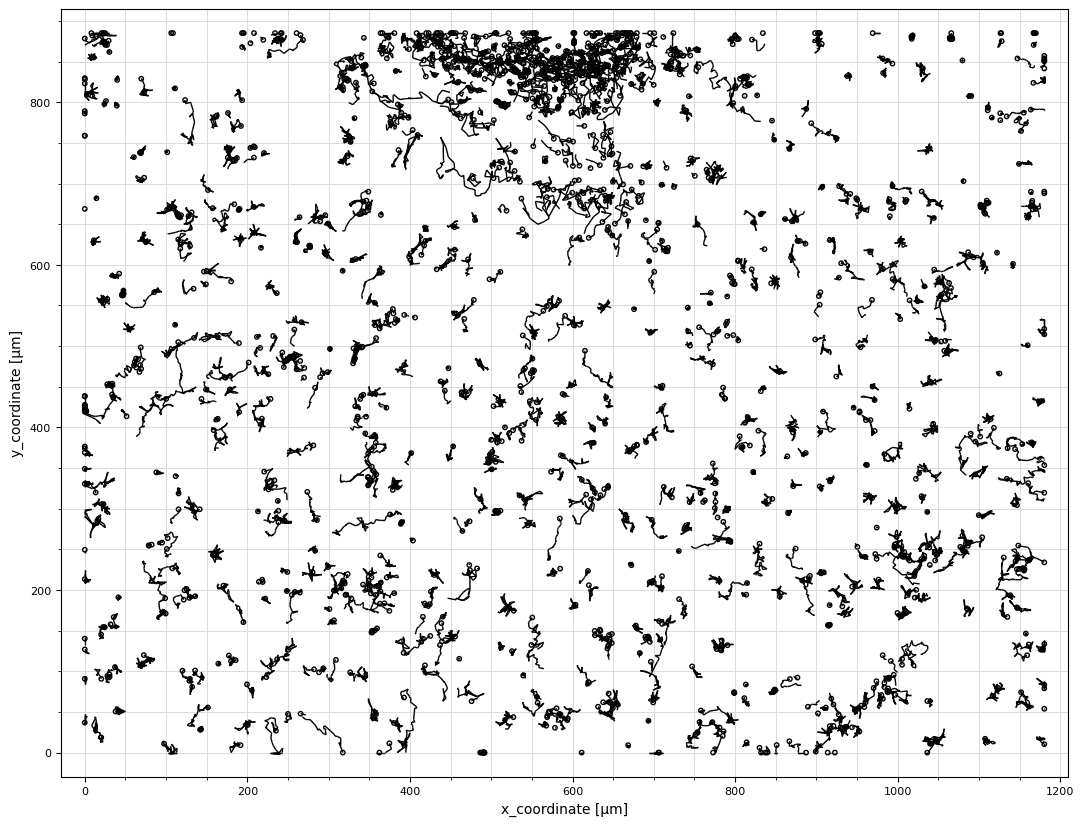

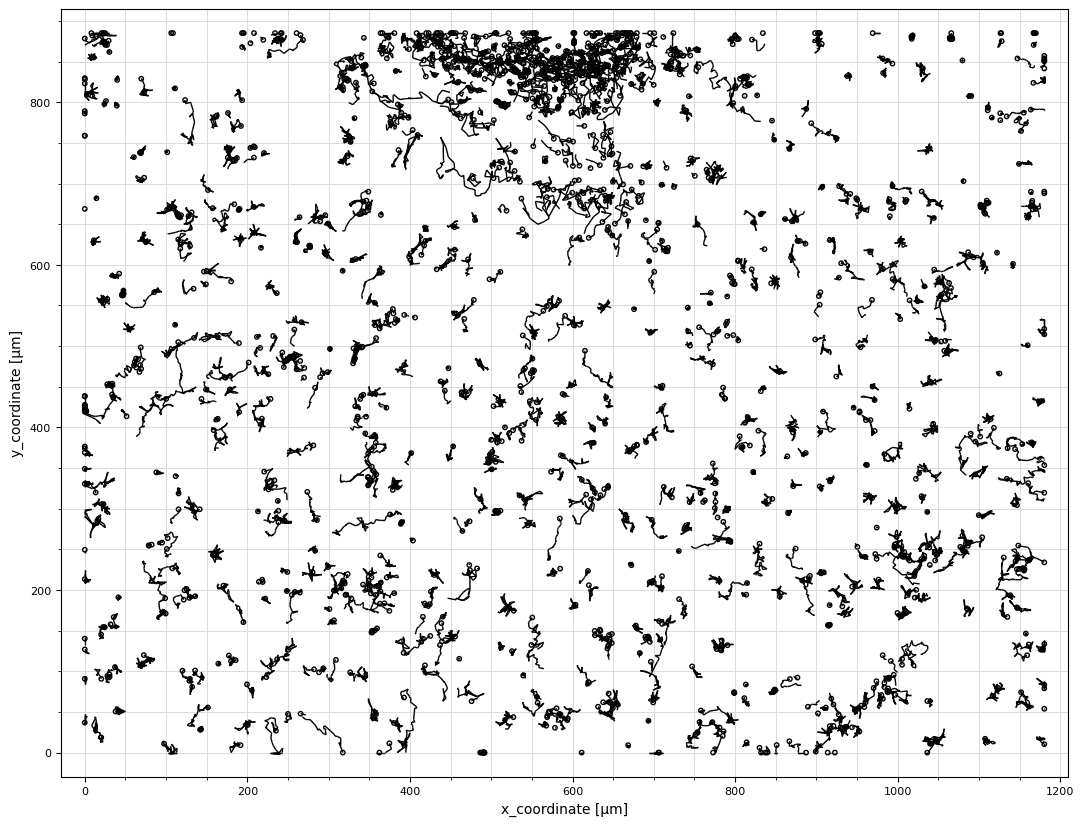

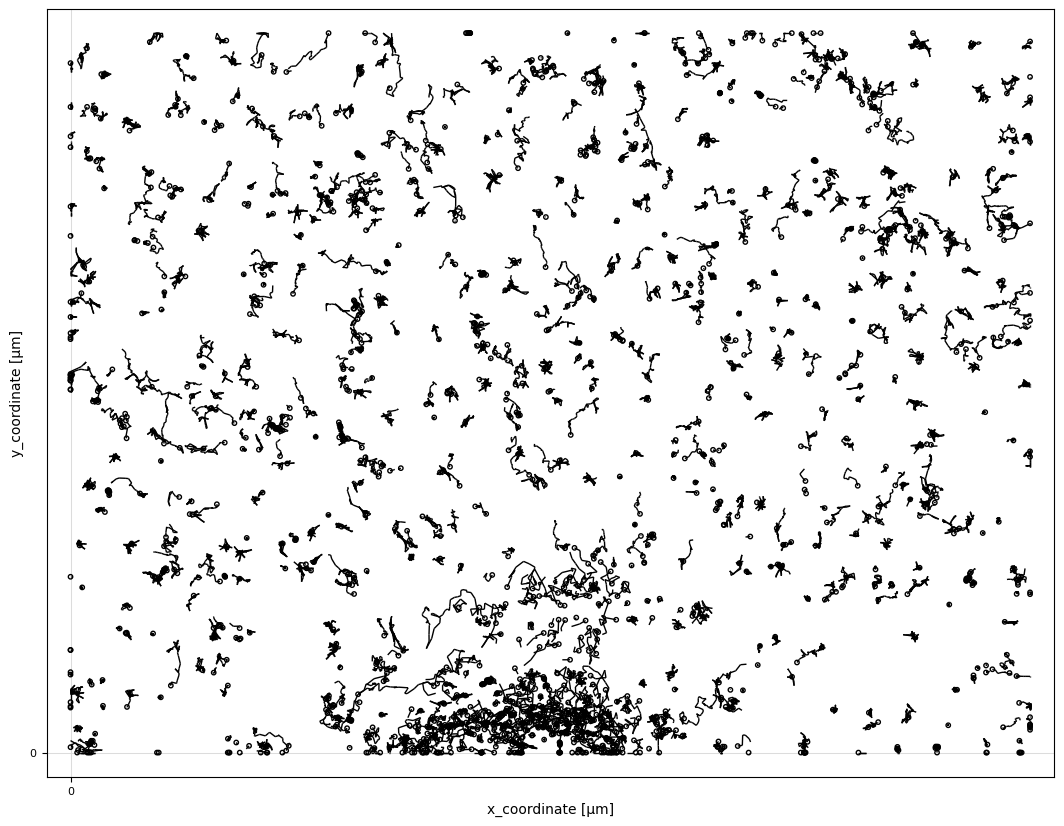

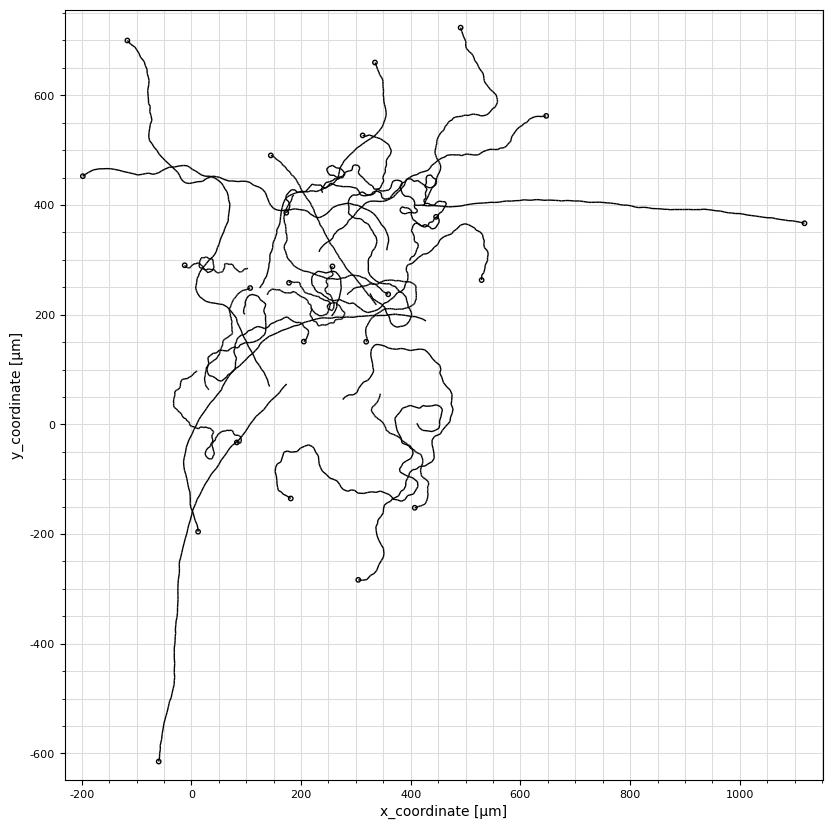

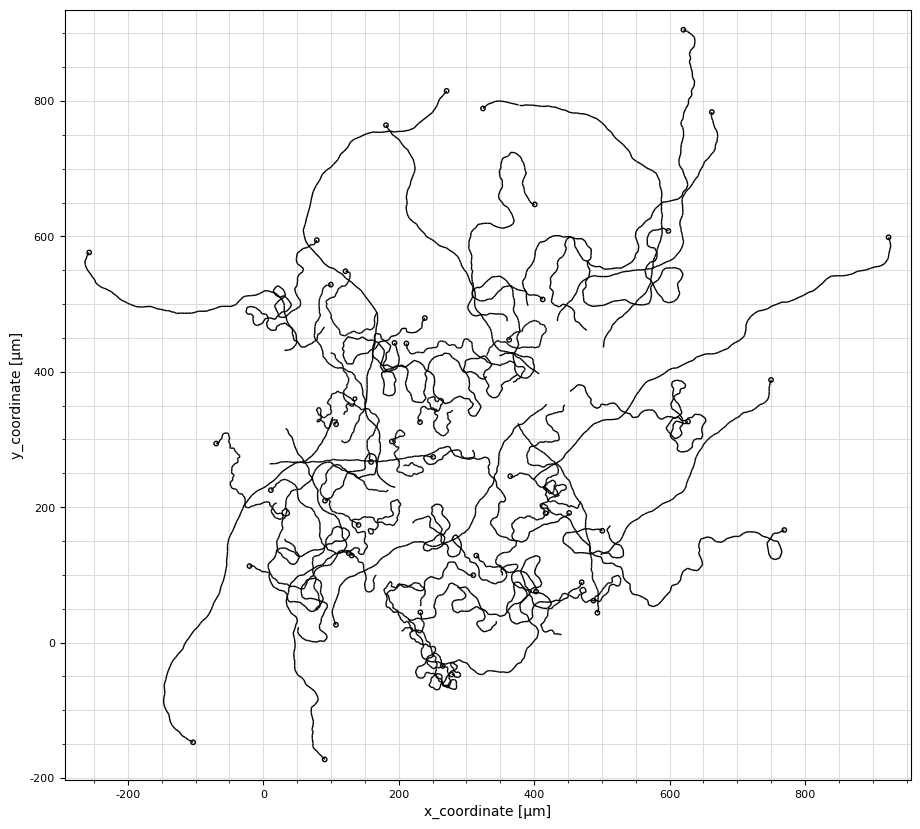

In [20]:
for d in data:
    object_ = create_object(d)
    object_.plot_tracks()